# Data Preparation and Exploratory Data Analysis (EDA)

The goal of this notebook is to perform an initial analysis of training data from a Garmin watch, clean it, and prepare it for the subsequent predictive modeling stage.

The scope of work includes:
- characterizing the structure and quality of the data,
- identifying missing values and potential outliers,
- preparing the dataset for the model training process,
- saving the processed dataset to a file.

This notebook serves as the preparatory stage for training intensity modeling, carried out in Notebook 02.

# Library Imports and Environment Configuration

In the first step, the libraries necessary for conducting the exploratory data analysis were imported, and visualization settings were configured to ensure consistency of the presented results.

In [1]:
# Base libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization and display settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

# Rendering Markdown in notebook via Code
from IPython.display import Markdown, display   

# Loading the Dataset

The raw training data exported from the **Garmin Connect** platform was loaded (period: *27.12.2023–27.01.2026*).

## Input Data Characteristics

The data used in the project covers the **author's physical activity history**. The dataset comes from a single user, which limits the generalizability of the results.

Each observation corresponds to a single training session and contains information about duration, physiological parameters, and descriptive metadata.

In [2]:
df = pd.read_csv('../data/raw/Activities.csv')

N, M = df.shape
display(Markdown(f"The dataset contains **{N} observations** and **{M} variables** describing physical activities, their duration, physiological parameters, and movement metrics."))

# Displaying the first observations allows for an initial assessment of the data structure, column types, and the way missing values are recorded
df.head()

The dataset contains **1340 observations** and **34 variables** describing physical activities, their duration, physiological parameters, and movement metrics.

,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Avg Bike Cadence,Max Bike Cadence,Avg Speed,Max Speed,Total Ascent,Total Descent,Avg Stride Length,Training Stress Score®,Steps,Total Reps,Total Poses,Min Temp,Decompression,Best Lap Time,Number of Laps,Max Temp,Stress Change,Stress Start,Stress End,Avg Stress,Max Stress,Moving Time,Elapsed Time,Min Elevation,Max Elevation
0,Yoga,2026-01-10 19:00:53,False,Yoga,--,173,00:43:17,92,136,--,--,--,--,--,--,--,0.0,--,--,--,28.0,No,00:43:17,1,31.0,-18,96,78,74,98,00:00:00,00:43:17,--,--
1,Cardio,2026-01-09 16:55:58,False,Boxing,0.00,658,01:03:33,145,179,--,--,--,--,--,--,--,0.0,--,--,--,19.0,No,01:03:33,1,26.0,--,--,--,--,--,00:00:00,01:03:33,-215,254
2,Cardio,2026-01-08 19:56:04,False,Boxing,0.00,798,01:11:37,148,196,--,--,--,--,--,--,--,0.0,--,--,--,19.0,No,01:11:37,1,25.0,--,--,--,--,--,00:00:00,01:11:37,-150,-141
3,Strength Training,2026-01-07 20:29:21,False,Strength,0.00,236,01:01:05,89,113,--,--,--,--,--,--,--,0.0,10,5,1,21.0,No,01:01:05,1,29.0,--,--,--,--,--,01:01:05,01:01:05,--,--
4,Yoga,2026-01-07 12:26:14,False,Yoga,--,83,00:15:58,102,119,--,--,--,--,--,--,--,0.0,--,--,--,28.0,No,00:15:58,1,29.0,90,0,90,88,97,00:00:00,00:15:58,--,--


At this stage, no modifications were made to the data; the sole purpose was to explore the structure and quality of the raw dataset.

# Data Structure and Types

Analysis of the dataset structure (`df.info()`) revealed that a significant portion of variables were loaded as **text (`object`/`str`)**, despite semantically representing numerical values. In subsequent steps, they will be appropriately converted to **float**. The exploration also revealed the presence of **'--'** values, acting as placeholders for missing data. In further stages, they are consistently treated as **NaN**.

As a consequence, the standard statistical description (`df.describe()`) does not cover most of the relevant features. To characterize them, **df.describe(include=['object', 'string'])** was applied, which allowed for assessing the count, uniqueness, and most frequent categories.

Additionally, the presence of duplicate observations was checked. The analysis (`df.duplicated().sum()`) revealed no duplicates, which is consistent with the fact that each observation corresponds to a single activity with a unique timestamp.

In [3]:
df.info()
df.describe(include=['object', 'string'])
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Activity Type           1340 non-null   str    
 1   Date                    1340 non-null   str    
 2   Favorite                1340 non-null   bool   
 3   Title                   1340 non-null   str    
 4   Distance                1340 non-null   str    
 5   Calories                1340 non-null   str    
 6   Time                    1340 non-null   str    
 7   Avg HR                  1340 non-null   str    
 8   Max HR                  1340 non-null   str    
 9   Avg Bike Cadence        1340 non-null   str    
 10  Max Bike Cadence        1340 non-null   str    
 11  Avg Speed               1340 non-null   str    
 12  Max Speed               1340 non-null   str    
 13  Total Ascent            1340 non-null   str    
 14  Total Descent           1340 non-null   str    
 15

np.int64(0)

# Activity Type Filtering

Prior to further analysis, the number of observations for each activity type was assessed.

This allowed for the identification of categories with **marginal representation**, which could reduce the stability and reliability of subsequent modeling.

In [4]:
df['Activity Type'].value_counts()

Activity Type
Yoga                            503
Cardio                          294
Strength Training               272
Walking                         204
Other                            36
Cycling                          13
Running                          11
Indoor Cycling                    2
Cross Country Classic Skiing      2
Indoor Running                    1
Stair Stepper                     1
Boxing                            1
Name: count, dtype: int64

## Activity Type Selection

To narrow the analysis to the most representative and comparable activities, the dataset was limited to four categories: **Cardio**, **Yoga**, **Strength Training**, and **Walking**.

Rare activities were discarded for **statistical** reasons — their low count makes reliable modeling difficult and increases the risk of overfitting.

## Activity-Specific Variables

| Activity Type | Specific Variables | Justification |
|---------------|--------------------|---------------|
| **Yoga** | `Avg Stress`, `Stress Change` | Garmin reports stress levels for recovery-type activities. |
| **Strength Training** | `Total Reps`, `Total Poses` | Describe strength training volume; not present in other activities. |
| **Walking** | `Distance`, `Steps` | Key features describing movement volume during walking. |
| **Cardio** | - | Garmin does not report additional metrics unique to this activity type. |

In [5]:
allowed_activities = ['Yoga', 'Cardio', 'Strength Training', 'Walking']

df = df[df['Activity Type'].isin(allowed_activities)].copy()
df['Activity Type'].value_counts()

Activity Type
Yoga                 503
Cardio               294
Strength Training    272
Walking              204
Name: count, dtype: int64

# Feature Reduction

The dataset contained many columns that were specific to individual activities, almost always empty, or did not contribute information relevant to training intensity.

Feature reduction was performed based on **semantic analysis**, **availability at prediction time**, and an assessment of **data leakage** risk.

## Categories of Removed Variables and Justification for Their Exclusion

| Variable Category | Example Columns | Justification for Removal |
|-------------------|-----------------|---------------------------|
| **Identification / metadata** | `Title`, `Favorite` | Carry no predictive information; describe activity metadata or user preferences. |
| **Specific to rare activities** | `Avg Bike Cadence`, `Max Bike Cadence`, `Avg Speed`, `Max Speed`, `Total Ascent`, `Total Descent`, `Avg Stride Length`, `Min Elevation`, `Max Elevation`, `Best Lap Time`, `Number of Laps` | Appear exclusively in activities with marginal counts, which would result in a high proportion of missing values and model instability. |
| **Potential data leakage** | `Moving Time`, `Elapsed Time`, `Training Stress Score®` | `Moving Time` and `Elapsed Time` are strongly correlated with the target variable. `Training Stress Score®` has zero variance and contributes no information. |
| **Low variance or almost always empty variables** | `Decompression`, `Min Temp`, `Max Temp` | Appear sporadically or take a single value across the dataset. |

In [6]:
columns_to_drop = [
    'Favorite', 'Avg Bike Cadence', 'Max Bike Cadence', 'Avg Speed', 
    'Max Speed', 'Total Ascent', 'Total Descent', 'Avg Stride Length', 
    'Training Stress Score®', 'Min Temp', 'Max Temp', 'Decompression', 
    'Best Lap Time', 'Number of Laps', 'Min Elevation', 'Max Elevation',
    'Moving Time', 'Elapsed Time', 'Stress Start', 'Stress End', 'Max Stress',
    'Title'
]

df.drop(columns=[c for c in columns_to_drop if c in df.columns], inplace=True)
df.head()

,Activity Type,Date,Distance,Calories,Time,Avg HR,Max HR,Steps,Total Reps,Total Poses,Stress Change,Avg Stress
0,Yoga,2026-01-10 19:00:53,--,173,00:43:17,92,136,--,--,--,-18,74
1,Cardio,2026-01-09 16:55:58,0.00,658,01:03:33,145,179,--,--,--,--,--
2,Cardio,2026-01-08 19:56:04,0.00,798,01:11:37,148,196,--,--,--,--,--
3,Strength Training,2026-01-07 20:29:21,0.00,236,01:01:05,89,113,10,5,1,--,--
4,Yoga,2026-01-07 12:26:14,--,83,00:15:58,102,119,--,--,--,90,88


Detailed statistics have been omitted due to their limited interpretative value.

# Conversion of Numerical Variables from Text Format

Many numerical variables (e.g., `Avg HR`, `Max HR`, `Distance`) were loaded as **text**, despite semantically representing numerical values. Prior to exploratory analysis and modeling, they were converted to **float** type, and in the `Steps` column, the thousands separator (`,`) used in **Garmin** data was removed.

In [7]:
# Columns that should be numeric
num_cols = ['Avg HR', 'Max HR', 'Distance', 'Steps', 'Total Reps', 'Total Poses', 'Stress Change', 'Avg Stress'] 

# Remove thousands separators in Steps
df['Steps'] = df['Steps'].str.replace(',', '', regex=False) 

# Convert all columns to float
for col in num_cols: df[col] = pd.to_numeric(df[col], errors='coerce')

After converting text variables to numeric type, the proportion of missing values ​​in each column was analyzed.

In [8]:
df[num_cols].isna().mean().sort_values()

Avg HR           0.000000
Max HR           0.000000
Distance         0.395915
Avg Stress       0.604870
Stress Change    0.604870
Steps            0.626080
Total Poses      0.786332
Total Reps       0.786332
dtype: float64

**Missing Data Interpretation**

- `Avg HR`, `Max HR` — complete, available for all activities.
- `Distance`, `Steps` — present mainly in `Walking`; other activities naturally generate missing values.
- `Avg Stress`, `Stress Change` — characteristic exclusively of `Yoga`.
- `Total Reps`, `Total Poses` — specific to `Strength Training`.

Missing values are determined by the activity type (e.g., steps for Walking, stress for Yoga) and do not result from measurement errors.

# **Temporal Feature Engineering**

From the timestamp (`Date`), the variables `day_of_week` and `hour` were extracted. The `hour` variable was transformed into a cyclic representation (`hour_sin`, `hour_cos`).

The use of trigonometric functions preserves daily continuity (23:00 ≈ 0:00) and better captures the user's circadian rhythm.

In [9]:
# Convert date to datetime type
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d %H:%M:%S')

# Temporal feature extraction
df['day_of_week'] = df['Date'].dt.dayofweek
df['hour'] = df['Date'].dt.hour

# Cyclic representation
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df = df.drop(columns=['hour'])

df[['Date', 'day_of_week', 'hour_sin', 'hour_cos']].head()

,Date,day_of_week,hour_sin,hour_cos
0,2026-01-10 19:00:53,5,-9.659258e-01,0.258819
1,2026-01-09 16:55:58,4,-8.660254e-01,-0.500000
2,2026-01-08 19:56:04,3,-9.659258e-01,0.258819
3,2026-01-07 20:29:21,2,-8.660254e-01,0.500000
4,2026-01-07 12:26:14,2,1.224647e-16,-1.000000


# Target Variable Definition

Training intensity was defined as `calories_per_min`, representing **energy expenditure per unit of time**, calculated from `Calories` and `Time`. These variables are used solely for constructing the indicator and **are not used as predictors**.

## Diagnosis of Incorrect Calories Value Format

In the **Garmin Connect** data, some calorie values appeared in the format "1,002", which does not represent a decimal value but rather an abbreviated thousands notation (e.g., "1,002" = 1002 kcal). This pattern was verified based on physiological context and corrected prior to further analysis.

In [10]:
df['Calories'].sort_values().head()

1149       --
771     1,002
1212    1,004
740     1,020
108     1,021
Name: Calories, dtype: str

In [11]:
# Calories: Garmin error removal and conversion
cal = df['Calories'].replace('--', np.nan).astype(str)
mask = cal.str.match(r'^1,\d{1,3}$')
print('Number of values in the format 1,xxx:', mask.sum())

df['Calories'] = (
    cal.where(~mask, cal.str.replace(',', '.', regex=False).astype(float) * 1000)
       .pipe(pd.to_numeric, errors='coerce')
)
print(df['Calories'].sort_values())

# Time => minutes
df['Time'] = pd.to_timedelta(df['Time']).dt.total_seconds() / 60

Number of values in the format 1,xxx: 14
717        3.0
1094      10.0
671       10.0
1177      16.0
407       16.0
         ...  
159     1117.0
1292    1176.0
617     1287.0
860     1868.0
1149       NaN
Name: Calories, Length: 1273, dtype: float64


In [12]:
# Target
df['calories_per_min'] = df['Calories'] / df['Time']
df['calories_per_min'].describe()

count    1272.000000
mean        6.132157
std         2.887830
min         0.093216
25%         4.226744
50%         5.150344
75%         6.720984
max        27.740030
Name: calories_per_min, dtype: float64

# Exploratory Data Analysis (EDA)

The goal of the exploratory data analysis was to investigate the relationships between training intensity, measured by the `calories_per_min` indicator, and features describing the nature of the performed activity, in the context of their usefulness for subsequent predictive modeling.

## Target Variable Distribution Analysis

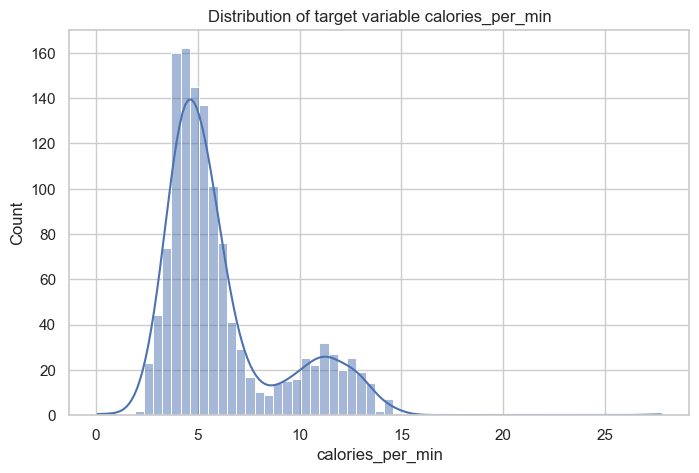

np.float64(1.48945634413599)

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['calories_per_min'], kde=True)
plt.title('Distribution of target variable calories_per_min')
plt.show()

df['calories_per_min'].skew()

The distribution of the `calories_per_min` variable is right-skewed, with a concentration of observations around approximately 5 kcal/min and the presence of outliers corresponding to high-intensity training sessions.

The variable was kept in its original scale due to its interpretability. Potential non-linearities can be captured by non-linear models, so a logarithmic transformation was not applied.

## Intensity vs. Activity Type

To assess the relationship between training intensity and activity type, a box plot was used to present the distribution of the `calories_per_min` indicator across individual categories.

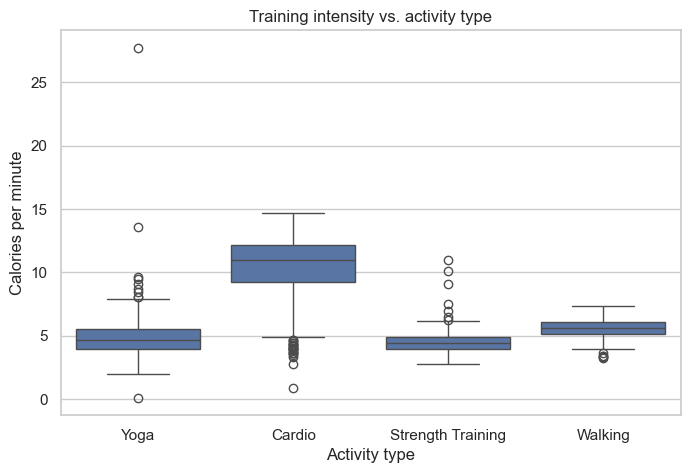

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Activity Type', y='calories_per_min')
plt.title('Training intensity vs. activity type')
plt.xlabel('Activity type')
plt.ylabel('Calories per minute')
plt.show()

Significant differences were observed in both the level and spread of intensity across activity types. At the same time, partial overlap of the distributions indicates that activity type does not unambiguously determine intensity, which justifies the inclusion of additional features in the modeling.

## HR vs. Intensity

In the next step, the relationship between average heart rate and training intensity was analyzed, differentiated by activity type.

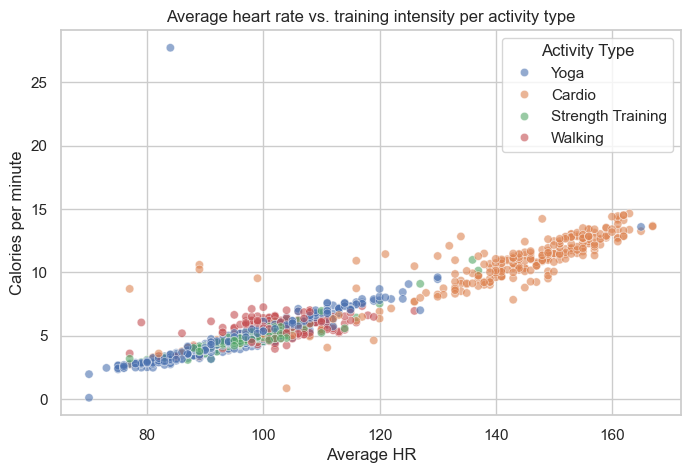

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Avg HR',
    y='calories_per_min',
    hue='Activity Type',
    alpha=0.6
)
plt.title('Average heart rate vs. training intensity per activity type')
plt.xlabel('Average HR')
plt.ylabel('Calories per minute')
plt.show()

A positive relationship was observed between average heart rate and training intensity, with the nature of the relationship varying across activity types. The partial overlap of the distributions confirms the validity of the regression approach and rules out a trivial mapping of activity type to intensity level.

## Yoga: Stress vs. Intensity

The variables `Avg Stress` and `Stress Change` are features specific to yoga activities and describe the physiological stress level of the body. In this part of the analysis, their relationship with training intensity was examined.

In [16]:
df_yoga = df[df['Activity Type'] == 'Yoga']

### Avg Stress vs. Intensity

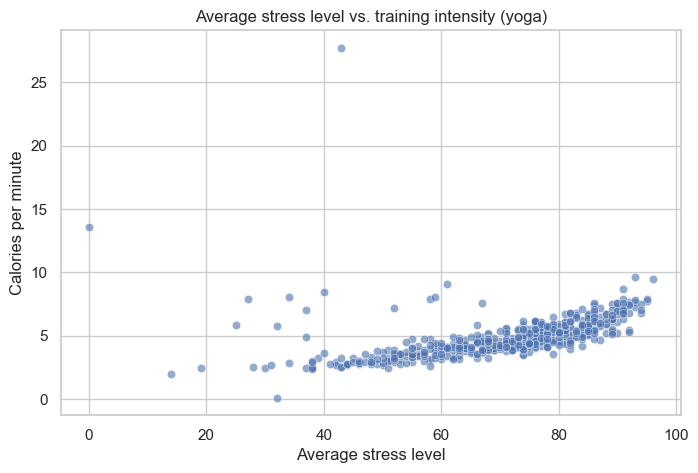

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_yoga,
    x='Avg Stress',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Average stress level vs. training intensity (yoga)')
plt.xlabel('Average stress level')
plt.ylabel('Calories per minute')
plt.show()

### Stress Change vs. Intensity

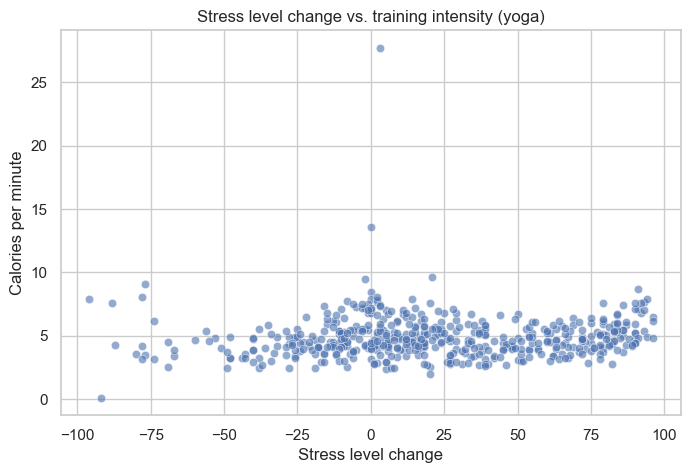

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_yoga,
    x='Stress Change',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Stress level change vs. training intensity (yoga)')
plt.xlabel('Stress level change')
plt.ylabel('Calories per minute')
plt.show()

The variables `Avg Stress` and `Stress Change`, specific to yoga, show only a weak and diffuse relationship with training intensity. This may suggest a nonlinear or contextual nature of their influence.

## Gym: Training Volume vs. Intensity

The variables `Total Reps` and `Total Poses` describe the volume of strength training and only appear for strength training activities.

In [19]:
df_gym = df[df['Activity Type'] == 'Strength Training']

### Total Reps vs. Intensity

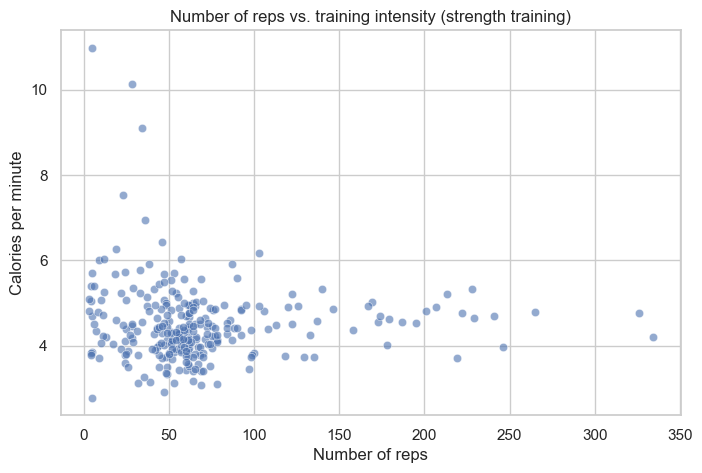

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_gym,
    x='Total Reps',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Number of reps vs. training intensity (strength training)')
plt.xlabel('Number of reps')
plt.ylabel('Calories per minute')
plt.show()

### Total Poses vs. Intensity

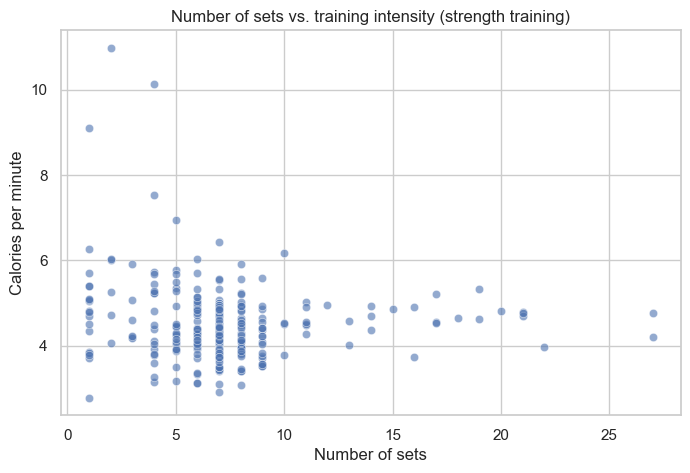

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_gym,
    x='Total Poses',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Number of sets vs. training intensity (strength training)')
plt.xlabel('Number of sets')
plt.ylabel('Calories per minute')
plt.show()

In the case of the gym, a weak positive correlation was observed between the number of repetitions (`Total Reps`) and the number of sets (`Total Poses`) and training intensity.

## Walking: Distance and Steps vs. Intensity

The variables `Distance` and `Steps` are characteristic of walking and describe movement volume.

In [22]:
df_walking = df[df['Activity Type'] == 'Walking']

### Steps vs. Intensity

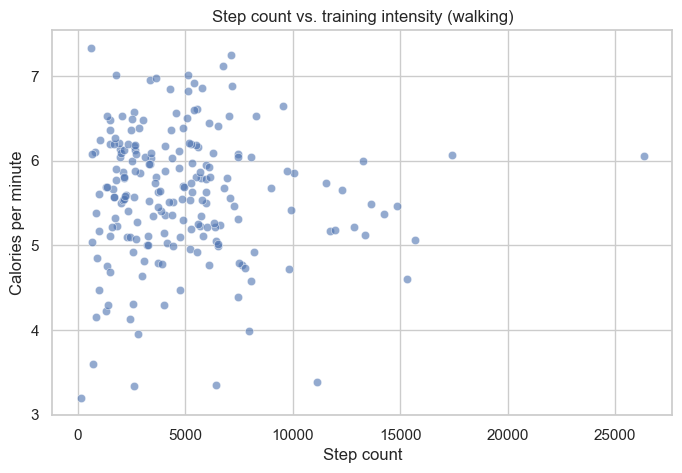

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_walking,
    x='Steps',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Step count vs. training intensity (walking)')
plt.xlabel('Step count')
plt.ylabel('Calories per minute')
plt.show()

### Distance vs. Intensity

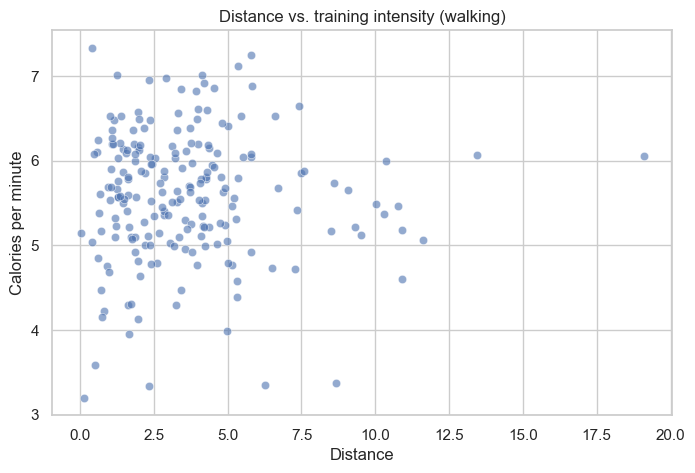

In [24]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_walking,
    x='Distance',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Distance vs. training intensity (walking)')
plt.xlabel('Distance')
plt.ylabel('Calories per minute')
plt.show()

Analysis of walking activities indicates that training intensity is not determined solely by distance or number of steps, suggesting an important role of pace and individual physiological characteristics.

## Summary

Analyses specific to activity types indicate that volume-based features (distance, number of reps, step count) may be helpful but insufficient to explain intensity. The strongest relationships are observed for physiological parameters, particularly heart rate. Stress-related and volume-based features exhibit weak or non-linear relationships, while temporal features serve a contextual role. This justifies the inclusion of physiological parameters and contextual features in further modeling.

# Outlier Analysis

The boxplot reveals the presence of individual observations with very high intensity (above 25 kcal/min). These values represent extreme observations relative to the distribution of the target variable and deviate significantly from the remaining training sessions.

Due to their marginal count and potentially destabilizing effect on regression models, observations with intensity above 22 kcal/min were removed from the dataset prior to further modeling.

<Axes: xlabel='calories_per_min'>

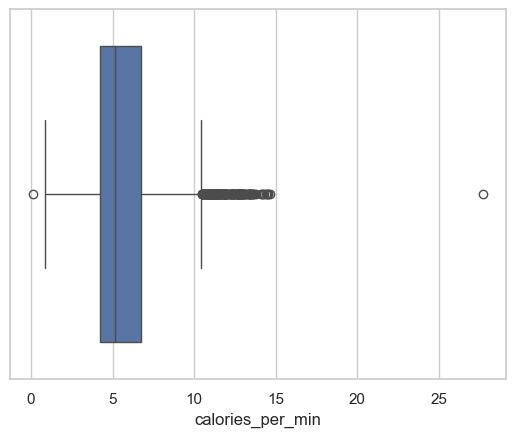

In [25]:
sns.boxplot(x=df['calories_per_min'])

In [26]:
# Number of observations before filtering
before = df.shape[0]

# Removing unrealistic intensity values
df = df[df['calories_per_min'] <= 22].copy()

# To assess the impact of outlier filtering, the number of observations removed based on the physiological threshold of 22 kcal/min was calculated.
after = df.shape[0]

removed = before - after
removed, removed / before

# Only 2 observations were removed (0.16% of the dataset),
# indicating that the filtering was conservative and did not significantly affect the representativeness of the data.

(2, 0.0015710919088766694)

## Quantitative Dependency Analysis – Spearman Rank Correlation

To assess the strength and direction of relationships between numerical variables and training intensity, Spearman rank correlation coefficients were calculated. This method is less sensitive to outliers and captures monotonic, including non-linear, relationships.

The analysis was conducted exclusively on numerical variables, following prior conversion of text columns to `float` type. The correlation values, ordered relative to the target variable `calories_per_min`, are presented below.

In [27]:
# Spearman's rank correlation for numerical variables
cols_for_corr = df.select_dtypes(include=['float64', 'int64', 'int32']).columns 
cols_for_corr = cols_for_corr.drop(['Calories', 'Time']) 
corr = df[cols_for_corr].corr(method='spearman') 

corr['calories_per_min'].sort_values(ascending=False)

calories_per_min    1.000000
Avg HR              0.943437
Avg Stress          0.771649
Max HR              0.636877
Steps               0.498441
hour_cos            0.224714
Stress Change       0.118775
Distance           -0.034473
Total Reps         -0.038646
day_of_week        -0.056212
Total Poses        -0.094636
hour_sin           -0.292534
Name: calories_per_min, dtype: float64

**Summary**

The strongest monotonic relationship with training intensity is exhibited by average heart rate (*Spearman ≈ 0.94*), confirming its key role as a predictor of energy expenditure. High correlations are also observed for `Avg Stress` and `Max HR`.

Volume-based and temporal features show weaker relationships, indicating that intensity is primarily determined by physiological parameters. Lower correlations of activity-specific variables result from their limited availability across the entire dataset.

# Exploratory Data Analysis Summary

The conducted analysis revealed significant differences in training intensity across activity types and clear relationships between physiological parameters (particularly average heart rate) and exercise intensity.

Activity-specific variables did not show strong linear relationships, but revealed distributional variation and potential non-linear relationships that may be captured by tree-based models.

On this basis, a set of features was selected for further modeling, the next stage of which involves data preparation and the construction of predictive models.

# Dataset Preparation for Modeling

The final dataset (`df_model`) contains only those features that can be used as predictors in the machine learning process, along with the target variable `calories_per_min`. At this stage, the data is fully prepared for the construction and evaluation of predictive models.

In [28]:
# Raw timestamps were previously processed into temporal features, so the 'Date' column is no longer needed
df_model = df.drop(columns=['Date'])

# The 'Calories' and 'Time' columns were used to calculate the target variable and keeping them would lead to data leakage
df_model = df_model.drop(columns=['Calories', 'Time'])

# Standardizing missing data: replacing Garmin's symbolic '--' values with NaN
df_model = df_model.replace('--', np.nan)

# Retaining activity-specific variables only for the corresponding activities.
# In all other cases, values were replaced with NaN to reduce information noise.
df_model.loc[df_model['Activity Type'] != 'Yoga', ['Stress Change', 'Avg Stress']] = np.nan # yoga-specific variables
df_model.loc[df_model['Activity Type'] != 'Strength Training', ['Total Reps', 'Total Poses']] = np.nan # strength training-specific variables
df_model.loc[df_model['Activity Type'] != 'Walking', ['Distance', 'Steps']] = np.nan # walking-specific variables

In [29]:
# Checking the number of missing values in each column
df_model.isna().sum().sort_values(ascending=False)

Steps               1068
Distance            1067
Total Reps           999
Total Poses          999
Stress Change        769
Avg Stress           769
Max HR                 0
Activity Type          0
Avg HR                 0
day_of_week            0
hour_sin               0
hour_cos               0
calories_per_min       0
dtype: int64

**Interpretation**

- `Distance`, `Steps` – available exclusively for Walking activities.
- `Total Reps`, `Total Poses` – characteristic of Strength Training.
- `Avg Stress`, `Stress Change` – present only in Yoga.
- `Avg HR`, `Max HR`, temporal features, binary features – complete.

Missing values are structural in nature and result from the fact that different activity types report different metrics — they indicate that a given feature does not apply to a specific activity.

### Final Structural and Semantic Validation of df_model

In [30]:
errors = {}

# Verifying completeness of mandatory variables
required_non_null = [
    'Activity Type', 'Avg HR', 'Max HR',
    'day_of_week', 'hour_sin', 'hour_cos', 
    'calories_per_min'
]
errors['missing_required'] = df_model[required_non_null].isna().sum()

# Validating category correctness
valid_activity = ['Yoga', 'Cardio', 'Strength Training', 'Walking']
errors['invalid_activity_type'] = df_model[~df_model['Activity Type'].isin(valid_activity)]

# Checking numerical value ranges
errors['invalid_hr'] = df_model[(df_model['Avg HR'] <= 0) | (df_model['Max HR'] < df_model['Avg HR'])]
errors['invalid_hour'] = df_model[ 
    (df_model['hour_sin'] < -1) | (df_model['hour_sin'] > 1) | 
    (df_model['hour_cos'] < -1) | (df_model['hour_cos'] > 1) | 
    (np.abs(df_model['hour_sin']**2 + df_model['hour_cos']**2 - 1) > 0.01) 
    ]
errors['invalid_day_of_week'] = df_model[(df_model['day_of_week'] < 0) | (df_model['day_of_week'] > 6)]

# Verifying absence of negative values in features describing training volume
volume_cols = ['Distance', 'Steps', 'Total Reps', 'Total Poses', 'Avg Stress']
errors['negative_values'] = df_model[(df_model[volume_cols] < 0).any(axis=1)]

# Validating the target variable
errors['invalid_calories'] = df_model[df_model['calories_per_min'] <= 0]

# Checking for duplicates
errors['duplicates'] = df_model[df_model.duplicated()]

# Semantic validation of activity-type-specific features
required_features = {
    'Yoga': ['Avg Stress', 'Stress Change'],
    'Strength Training': ['Total Reps', 'Total Poses'],
    'Walking': ['Steps', 'Distance'],
    'Cardio': []  # no activity-specific features
}

invalid_semantic_masks = []

for activity, cols in required_features.items():
    if not cols:
        continue  # no activity-specific features to validate

    mask = (df_model['Activity Type'] == activity)
    for col in cols:
        mask &= (df_model[col] == 0.0) # activity-specific feature has value 0.0

    mask &= (df_model['calories_per_min'] > 0)
    invalid_semantic_masks.append(mask)

if invalid_semantic_masks:
    invalid_semantic_mask = np.logical_or.reduce(invalid_semantic_masks) # combining multiple masks into one
    errors['invalid_semantic'] = df_model[invalid_semantic_mask]
else:
    errors['invalid_semantic'] = pd.DataFrame()

# Validation results summary
for name, err in errors.items():
    if isinstance(err, pd.Series):
        print(f"{name}: {err.sum()}")
    else:
        print(f"{name}: {len(err)}")

missing_required: 0
invalid_activity_type: 0
invalid_hr: 0
invalid_hour: 0
invalid_day_of_week: 0
negative_values: 0
invalid_calories: 0
duplicates: 0
invalid_semantic: 1


In [31]:
# Removal of identified semantic artifact
df_model = df_model[~invalid_semantic_mask]

The final semantic validation detected a single record in which activity-specific features (e.g., `Avg Stress`, `Stress Change` for yoga) had a value of 0.0 despite a positive intensity. It was treated as a measurement artifact and removed prior to modeling.

## Missing Data Handling Strategy in Modeling

Tree-based algorithms tolerant of missing values will be used in modeling.

These models treat missing values as a separate decision branch, which preserves the structural information resulting from the heterogeneity of physical activities.

In the context of data from wearable devices, this is the most natural approach and consistent with their semantics.

## Preview of the Final Dataset

In [32]:
df_model.head()

,Activity Type,Distance,Avg HR,Max HR,Steps,Total Reps,Total Poses,Stress Change,Avg Stress,day_of_week,hour_sin,hour_cos,calories_per_min
0,Yoga,NaN,92,136,NaN,NaN,NaN,-18.0,74.0,5,-9.659258e-01,0.258819,3.996920
1,Cardio,NaN,145,179,NaN,NaN,NaN,NaN,NaN,4,-8.660254e-01,-0.500000,10.354052
2,Cardio,NaN,148,196,NaN,NaN,NaN,NaN,NaN,3,-9.659258e-01,0.258819,11.142658
3,Strength Training,NaN,89,113,NaN,5.0,1.0,NaN,NaN,2,-8.660254e-01,0.500000,3.863574
4,Yoga,NaN,102,119,NaN,NaN,NaN,90.0,88.0,2,1.224647e-16,-1.000000,5.198330


After removing observations with unrealistic intensity and a single semantic artifact, the final set includes **1270 observations**.

In [33]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 1270 entries, 0 to 1339
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Activity Type     1270 non-null   str    
 1   Distance          204 non-null    float64
 2   Avg HR            1270 non-null   int64  
 3   Max HR            1270 non-null   int64  
 4   Steps             203 non-null    float64
 5   Total Reps        272 non-null    float64
 6   Total Poses       272 non-null    float64
 7   Stress Change     501 non-null    float64
 8   Avg Stress        501 non-null    float64
 9   day_of_week       1270 non-null   int32  
 10  hour_sin          1270 non-null   float64
 11  hour_cos          1270 non-null   float64
 12  calories_per_min  1270 non-null   float64
dtypes: float64(9), int32(1), int64(2), str(1)
memory usage: 143.7 KB


The difference in the number of non-null values for `Distance` and `Steps` is due to the fact that Garmin does not always report both metrics simultaneously — this does not indicate an error in the data.

The categorical variable (`Activity Type`) will be encoded using one-hot encoding. Missing values in numerical variables will remain marked as `NaN` and will be handled by tree-based algorithms.

## Final Model Features with Data Type and Semantic Description
| Feature Name       | Data Type | Semantic Description                                                                 |
|--------------------|-----------|--------------------------------------------------------------------------------------|
| **Activity Type**  | categorical (str) | Type of performed activity (Yoga, Cardio, Strength Training, Walking).     |
| **Distance**       | float     | Distance covered during a Walking activity; missing value indicates the feature does not apply to the given activity. |
| **Avg HR**         | int       | Average heart rate during training; the primary physiological predictor of intensity. |
| **Max HR**         | int       | Maximum heart rate reached during the session; information about peak load.          |
| **Steps**          | float     | Step count (Walking); missing value indicates the feature does not apply to the activity. |
| **Total Reps**     | float     | Number of repetitions in strength training; missing value indicates the feature does not apply to the activity. |
| **Total Poses**    | float     | Number of sets/positions in strength training; missing value indicates the feature does not apply to the activity. |
| **Stress Change**  | float     | Change in stress level (Yoga); missing value indicates the feature does not apply to the activity. |
| **Avg Stress**     | float     | Average stress level (Yoga); missing value indicates the feature does not apply to the activity. |
| **day_of_week**    | int       | Day of the week (0–6); may reflect the user's training rhythm.                       |
| **hour_sin**       | float     | Cyclic representation of the hour (sine component); models the circadian rhythm.     |
| **hour_cos**       | float     | Cyclic representation of the hour (cosine component); complements hour_sin.          |
| **calories_per_min** | float   | Target variable: training intensity expressed as energy expenditure per minute.      |

# Summary

The `df_model` dataset constitutes a complete and validated set of input data for building predictive models.

It was saved in Parquet format, which ensures preservation of variable types, compression, and fast reading:

In [34]:
df_model.to_parquet('../data/processed/activities_model_ready.parquet', index=False)